In [36]:
import networkx as nx
import matplotlib.pyplot as plt
from random import randint
from random import random
import csv

In [38]:
#Generate Grid with random edge lengths
def GenGrid(l,w,r):
    Grid = [[0 for k in range(l*w)] for y in range(l*w)]
    for i in range(l*w):
        for j in range(w*l):
            if Grid[j][i] != 0:
                Grid[i][j] = Grid[j][i]
            else:
                if ((j == i - 1) or (j == i + 1) or (j == i + w) or (j == i - w)):
                    Grid[i][j] = round((r[1]-r[0]) * random() + r[0],2)
                if ((i+1)%w == 0 and j == i + 1) or (i%w == 0 and j == i - 1):
                    Grid[i][j] = 0
    return Grid
            

In [39]:
# Visualise Route with Weighted Edges from Adjacency Matrix
def VisualiseRoute(adj_matrix, path, w, l):
    G = nx.Graph()

    # Create grid layout positions
    pos = {}
    for i in range(len(adj_matrix)):
        row = i // w
        col = i % w
        pos[i] = (col, -row)

    for i, row_vals in enumerate(adj_matrix):
        for j, weight in enumerate(row_vals):
            if weight > 0 and i < j:  # <-- FIXED
                G.add_edge(i, j, weight=weight)

    path_edges = list(zip(path, path[1:]))

    plt.figure(figsize=(8, 6))

    nx.draw(
        G, pos,
        with_labels=True,
        node_color="skyblue",
        node_size=500,
        font_weight="bold",
        edge_color="gray"
    )

    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=edge_labels,
        font_size=14,
        font_weight="bold"
    )

    nx.draw_networkx_edges(
        G, pos,
        edgelist=path_edges,
        edge_color="red",
        width=3,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=20
    )

    nx.draw_networkx_nodes(
        G, pos,
        nodelist=path,
        node_color="orange",
        node_size=600
    )

    total_cost = sum(G[u][v]['weight'] for u, v in path_edges)

    plt.axis("equal")
    plt.savefig("Graph.png")
    plt.show()

In [4]:
def FixedDemand(l,w, D):
    Passenger = [D]
    return Passenger * l * w

In [5]:
def NearestNode(distances, CheckedNode):
    best = [0,9999]
    for i in distances:
        if i not in CheckedNode and distances[i] < best[1]:
            best = [i,distances[i]]
    return best

In [40]:
def CheckNeighbours(adj_matrix,path,Stops,Node,CheckedNode,distances):
    
    CheckedNode.append(Node[0])   
    if Node[0] in path:
        Stops.append(Node[0])
    
    for i in range(len(adj_matrix)):
        dist = adj_matrix[Node[0]][i]
        if dist != 0 and not i in CheckedNode:
            if i in distances:
                if Node[1] + dist < distances[i]:
                    distances[i] = Node[1] + dist
            else:
                distances[i] = Node[1] + dist


    
    return distances, Stops, CheckedNode

In [41]:
def NearestStop(adj_matrix,path,Node,k2,k3):
    if Node in path:
        Current = Node
        Dis = 0
        while Current != path[-1]:
            Dis += adj_matrix[Current][path[path.index(Current)+1]]
            Current = path[path.index(Current)+1]
        return k3 * Dis
    CheckedNode = []
    distances = {Node : 0}
    Stops = []
    while len(Stops) < len(path):
        Nearest = NearestNode(distances,CheckedNode)
        distances, Stops, CheckedNode = CheckNeighbours(adj_matrix, path, Stops, Nearest, CheckedNode, distances)

    #Bus distance calc
    BusDis = [0]
    for i in range(len(path)-1):
        BusDis.insert(0,adj_matrix[path[-(i+1)]][path[-i-2]] + BusDis[0])
        
    pathcost = []
    for i in path:
        pathcosti = k2 * distances[i] + k3 * BusDis[path.index(i)]
        pathcost.append(pathcosti)
    return min(pathcost)
    
    


In [8]:
def BusCost(adj_matrix,path,k1):
    Sum = 0
    for i in range(len(path)-1):
        Sum += adj_matrix[path[i]][path[i+1]]
    return k1* Sum

In [9]:
def PassengerCost(adj_matrix,Demand,path, k2, k3):
    total = 0
    n = 0
    for i in Demand:
        total += i * NearestStop(adj_matrix,path,n,k2,k3)
        n += 1
    return total

In [10]:
def TotalCost(adj_matrix,Demand,path, k1,k2,k3):
    TotalCost = PassengerCost(adj_matrix,Demand,path, k2, k3) + BusCost(adj_matrix,path,k1)
    return TotalCost

In [11]:
def FindNeighbours(adj_matrix, Node, route):
    Neighbours = []
    for i in range(len(adj_matrix)):
        if adj_matrix[Node][i] != 0 and not i in route:
            Neighbours.append(i)
    return Neighbours

In [42]:
def ExtendRoute2(adj_matrix, Destination, Checked, route, New):
    Tree = FindNeighbours(adj_matrix, route[-1], route)
    if len(Tree) > 0:
        for i in Tree:
            if not (str(route),i) in Checked:
                if Destination == i:
                    route.append(Destination)
                    New.append(route[:])
                    Checked[str(route[0:-1]),i] = 1
                    route.pop(-1)
                else:
                    route.append(i)
                    ExtendRoute2(adj_matrix, Destination, Checked, route, New)
    
    Checked[str(route[0:-1]),route[-1]] = 1
    route.pop(-1)
    return New
        

In [43]:
def ExhaustiveSearch(adj_matrix, k1,k2,k3, Destination):
    Routes = []
    Checked = {}
    New = []
    for i in range(len(adj_matrix)):
        if i == Destination:
            Routes.append([i])
        else:
            route = [i]
            New = ExtendRoute2(adj_matrix, Destination, Checked, route, New)
            for j in New:
                if not j in Routes:
                    Routes.append(j)
    return Routes


In [44]:
def ExhaustiveOptimal(adj_matrix, Demand, k1, k2, k3, Destination, filename="routes.csv"):
    Routes = ExhaustiveSearch(adj_matrix, k1, k2, k3, Destination)
    best = [[Destination], TotalCost(adj_matrix, Demand, [Destination], k1, k2, k3)]
    extras = []
    
    with open(filename, "w", newline="") as file:
        writer = csv.writer(file)
        
        writer.writerow(["Route", "Length", "Cost"])

        for route in Routes:
            route_cost = TotalCost(adj_matrix, Demand, route, k1, k2, k3)
            route_length = len(route)

            writer.writerow([route, route_length, route_cost])

            if route_cost == best[1]:
                extras.append([route, route_cost])
            
            if route_cost < best[1]:
                extras = []
                best = [route, route_cost]

    return best, extras

In [16]:
def Simulate(l,w,r, Demand, k1,k2,k3, Destination, n):
    OptRoutes = [[],[]]
    for i in range(n):
        adj_matrix = GenGrid(l,w,r)
        Route,cost = ExhaustiveOptimal(adj_matrix, Demand, k1,k2,k3, Destination)
        if Route[0]in OptRoutes[0]:
            index = OptRoutes[0].index(Route[0])
            OptRoutes[1][index] += 1
        else:
            OptRoutes[0].append(Route[0])
            OptRoutes[1].append(1)
    return OptRoutes

In [17]:
def Degree(adj_matrix,Node, Checked):
    n = 0
    total = 0
    for i in adj_matrix[Node]:
        if i != 0 and not n in Checked:
            total += 1
        n += 1
    return total

In [18]:
def FindNeighbours2(adj_matrix, Node, Checked):
    Neighbours = []
    for i in range(len(adj_matrix)):
        if adj_matrix[Node][i] != 0 and not i in Checked:
            Neighbours.append(i)
    return Neighbours

In [45]:
def BackwardsSearch(adj_matrix, Demand, k1,k2,k3, Destination):
    Route = [Destination]
    Checked = [Destination]
    
    CurrentCost = TotalCost(adj_matrix,Demand,Route, k1,k2,k3)
    NewCost = CurrentCost - 1
    while NewCost < CurrentCost:
        Neigh = FindNeighbours2(adj_matrix,Route[0],Checked)
        Degrees = [Degree(adj_matrix,i,Checked) for i in Neigh]
        
        Costs = []
        Options = []
        for i in range(len(Neigh)):
            if Degrees[i] == max(Degrees):
                NewRoute = Route[:]
                NewRoute.insert(0,Neigh[i])
                Costs.append(TotalCost(adj_matrix,Demand,NewRoute, k1,k2,k3))
                Options.append(NewRoute)
        
        Route = Options[Costs.index(min(Costs))]
        CurrentCost = NewCost
        NewCost = min(Costs)
        Checked.append(Route[0])
        
    return Route[1:], CurrentCost

In [46]:
def BackwardsSearch2(adj_matrix, Demand, k1,k2,k3, Destination):
    Route = [Destination]
    Checked = [Destination]
    
    CurrentCost = TotalCost(adj_matrix,Demand,Route, k1,k2,k3)
    NewCost = CurrentCost - 1
    
    total = 0
    
    while NewCost < CurrentCost:
        Neigh = FindNeighbours2(adj_matrix,Route[0],Checked)
        Costs = []
        Options = []
        for i in range(len(Neigh)):
            NewRoute = Route[:]
            NewRoute.insert(0,Neigh[i])
            total += 1
            Costs.append(TotalCost(adj_matrix,Demand,NewRoute, k1,k2,k3))
            Options.append(NewRoute)
            Checked.append(Neigh[i])
        
        Route = Options[Costs.index(min(Costs))]
        CurrentCost = NewCost
        NewCost = min(Costs)
        Checked.append(Route[0])
        
    print('Total routes checked', total)
    return Route[1:], CurrentCost

In [47]:
def ErrorCalc(l,w,r, Demand, k1,k2,k3, Destination, n):

    Errors1 = []
    Error1Per = []
    Errors2 = []
    Error2Per = []
    
    for i in range(n):
        adj_matrix = GenGrid(l,w,r)
        
        Exact = ExhaustiveOptimal(adj_matrix, Demand, k1,k2,k3, Destination)[0][1]
        BackSearch = BackwardsSearch3(adj_matrix, Demand, k1,k2,k3, Destination)[1]
        Route, SpecSearch = SpecifiedSearch(adj_matrix, Destination, Demand)
        Error1 = BackSearch - Exact
        Error1_per = Error1 / Exact * 100
        Error2 = SpecSearch - Exact
        Error2_per = Error2 / Exact * 100
        
        Errors1.append(Error1)
        Error1Per.append(Error1_per)
        Errors2.append(Error2)
        Error2Per.append(Error2_per)

    # Write to CSV
    with open("error_results.csv", mode="w", newline="") as file:
        writer = csv.writer(file)
        
        writer.writerow(["Iteration", "Error1_Percentage", "Error2_Percentage"])
        
        for i in range(n):
            writer.writerow([i+1, Error1Per[i], Error2Per[i]])
    
    pass

In [48]:
def MutualNeighbours(adj_matrix, Node1, Node2):
    Neigh1 = FindNeighbours2(adj_matrix, Node1, [])
    Neigh2 = FindNeighbours2(adj_matrix, Node2, [])
    Mutual = []
    for i in Neigh1:
        for j in Neigh2:
            if i == j:
                Mutual.append(i)
    return Mutual

In [49]:
def Annealing(adj_matrix,path,pathcost,Checked,total,Demand,k1,k2,k3):
    if path in Checked:
        Costs = [[],[]]
    else:
        Costs = [[path],[pathcost]]
    for i in range(len(path)-2):
        Mutuals = MutualNeighbours(adj_matrix, path[i], path[i+2])
        for j in Mutuals:
            if not j == path[i+1]:
                TempPath = path[:]
                TempPath[i+1] = j
                if not TempPath in Checked:
                    Costs[0].append(TempPath)
                    Costs[1].append(TotalCost(adj_matrix,Demand,TempPath, k1, k2, k3))
                    total += 1
    
    Route = Costs[0][Costs[1].index(min(Costs[1]))]
    
    return Route,min(Costs[1]), total

In [50]:
def SpecifiedStart(adj_matrix,start,destination,Demand,k1,k2,k3):
    if start == destination:
        Cost = TotalCost(adj_matrix,Demand,[start], k1, k2, k3)
        return Cost
    
    CheckedNode = []
    distances = {start : 0}
    Stops = []
    while len(distances) < len(adj_matrix):
        Nearest = NearestNode(distances,CheckedNode)
        distances, Stops, CheckedNode = CheckNeighbours(adj_matrix, [], Stops, Nearest, CheckedNode, distances)
    
    path = [destination]
    for j in range(len(adj_matrix)):
        if path[0] == start:
            break
        Neigh = FindNeighbours2(adj_matrix, path[0], [])
        for i in Neigh:
            dis = distances[path[0]] - adj_matrix[path[0]][i]
            if distances[i] == dis:
                path.insert(0,i)
                break
    
    pathcost = TotalCost(adj_matrix,Demand,path, k1, k2, k3)
    total = 1
    Options = [[],[]]
    while len(Options[0]) < 15 or total > 50:
        NewRoute, NewCost, total = Annealing(adj_matrix,path,pathcost,Options[0],total,Demand,k1,k2,k3)
        if NewCost < pathcost:
            pathcost = NewCost
            path = NewRoute
        elif (NewCost - pathcost) / pathcost <= 0.05:
            if not path in Options[0]:
                Options[1].append(pathcost)
                Options[0].append(path)
                pathcost = NewCost
                path = NewRoute
        else:
            Route = Options[0][Options[1].index(min(Options[1]))]
            return Route,min(Options[1])
    Route = Options[0][Options[1].index(min(Options[1]))]
    print('Total routes checked', total)
    return Route,min(Options[1])


In [51]:
def SpecifiedStart2(adj_matrix,start,destination,Demand,k1,k2,k3):
    if start == destination:
        Cost = TotalCost(adj_matrix,Demand,[start], k1, k2, k3)
        return [start], Cost
    
    CheckedNode = []
    distances = {start : 0}
    Stops = []
    while len(distances) < len(adj_matrix):
        Nearest = NearestNode(distances,CheckedNode)
        distances, Stops, CheckedNode = CheckNeighbours(adj_matrix, [], Stops, Nearest, CheckedNode, distances)
    
    path = [destination]
    for j in range(len(adj_matrix)):
        if path[0] == start:
            break
        Neigh = FindNeighbours2(adj_matrix, path[0], [])
        for i in Neigh:
            dis = distances[path[0]] - adj_matrix[path[0]][i]
            if distances[i] == dis:
                path.insert(0,i)
                break
    
    pathcost = TotalCost(adj_matrix,Demand,path, k1, k2, k3)
    
    return path,pathcost


In [52]:
def BackwardsSearch3(adj_matrix, Demand, k1,k2,k3, Destination):
    Route = [Destination]
    Checked = [Destination]
    
    CurrentCost = TotalCost(adj_matrix,Demand,Route, k1,k2,k3)
    NewCost = CurrentCost - 1
    
    total = 0
    
    while NewCost < CurrentCost:
        Neigh = FindNeighbours2(adj_matrix,Route[0],Checked)
        Costs = []
        Options = []
        if len(Neigh) == 0:
            return Route, NewCost
        for i in range(len(Neigh)):
            NewRoute = Route[:]
            NewRoute.insert(0,Neigh[i])
            total += 1
            Costs.append(TotalCost(adj_matrix,Demand,NewRoute, k1,k2,k3))
            Options.append(NewRoute)
            Checked.append(Neigh[i])
        
        Route = Options[Costs.index(min(Costs))]
        CurrentCost = NewCost
        NewCost = min(Costs)
        Checked.append(Route[0])

    Route.pop(0)
    Route, Cost, total = Annealing(adj_matrix,Route,CurrentCost,[],total,Demand,k1,k2,k3)
    
    print('Total routes checked', total)
    return Route, Cost

In [53]:
l = 4
w = 4
D = 2
r = [1,1]
adj_matrix = GenGrid(l,w,r)

In [54]:
k1 = 2.5   #Bus operating cost per km
k2 = 1.5    #Walk cost per km
k3 = 0.75   #Bus travel cost per km

Demand = FixedDemand(l,w,D)
Destination = 15

In [55]:
#print(ExhaustiveOptimal(adj_matrix, Demand, k1,k2,k3, Destination))
#SpecifiedStart(adj_matrix,0,63,Demand,k1,k2,k3)
BackwardsSearch3(adj_matrix, Demand, k1,k2,k3, Destination)

Total routes checked 15


([1, 5, 6, 10, 11, 15], 107.0)

In [56]:
path = [0, 1, 2, 3, 7, 11, 15]
TotalCost(adj_matrix,Demand,path, k1, k2, k3)

114.0

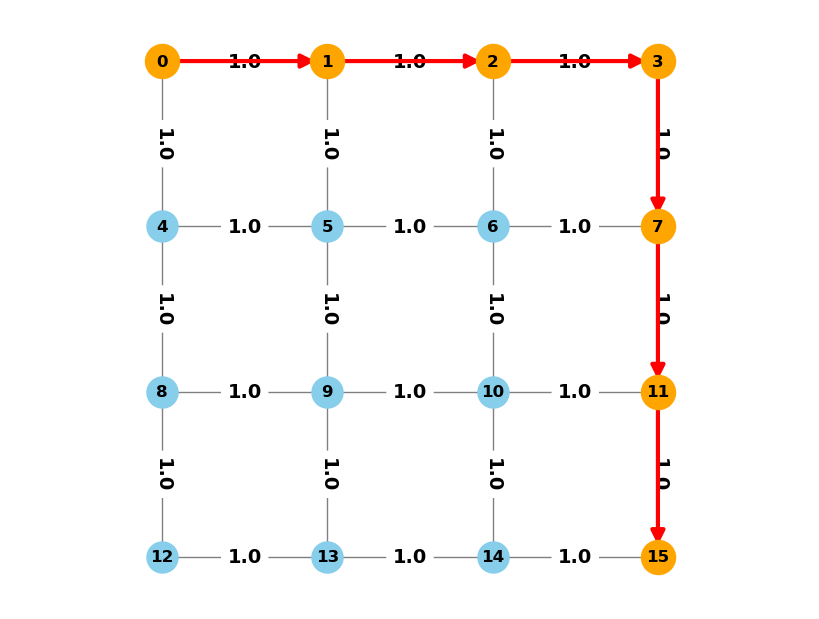

In [57]:
VisualiseRoute(adj_matrix, path, w, l)